In [2]:
import pandas as pd

In [5]:
import os

# Check your current directory
print(os.getcwd())

C:\Users\Komal


In [10]:
df = pd.read_csv(r'G:\Hajj_Heatstroke\daily_temparature_major_cities.csv', low_memory=False)
df_jeddah = df[df['City'] == 'Jeddah'].copy()

In [11]:
# Convert Fahrenheit to Celsius (CRITICAL — dataset is in Fahrenheit)
df_jeddah['temp_celsius'] = (df_jeddah['AvgTemperature'] - 32) * 5 / 9

# Basic statistics
print('Average temp (Celsius):', df_jeddah['temp_celsius'].mean())
print('Max temp (Celsius):', df_jeddah['temp_celsius'].max())
print('Min temp (Celsius):', df_jeddah['temp_celsius'].min())


Average temp (Celsius): nan
Max temp (Celsius): nan
Min temp (Celsius): nan


In [12]:
# Convert Fahrenheit to Celsius
df_jeddah['temp_celsius'] = (df_jeddah['AvgTemperature'] - 32) * 5 / 9

# Drop NaN and invalid values (-99 is often used as placeholder for missing)
df_jeddah = df_jeddah[df_jeddah['AvgTemperature'] != -99]
df_jeddah = df_jeddah.dropna(subset=['AvgTemperature'])

# Recalculate
df_jeddah['temp_celsius'] = (df_jeddah['AvgTemperature'] - 32) * 5 / 9

# Basic statistics
print('Average temp (Celsius):', df_jeddah['temp_celsius'].mean())
print('Max temp (Celsius):', df_jeddah['temp_celsius'].max())
print('Min temp (Celsius):', df_jeddah['temp_celsius'].min())

Average temp (Celsius): nan
Max temp (Celsius): nan
Min temp (Celsius): nan


In [13]:
print(df_jeddah.columns.tolist())       # check column names
print(df_jeddah['AvgTemperature'].head()) # check actual values

['Region', 'Country', 'State', 'City', 'Month', 'Day', 'Year', 'AvgTemperature', 'temp_celsius']
Series([], Name: AvgTemperature, dtype: float64)


In [15]:
def assign_risk(row):
    feels_like = row['feels_like']
    if feels_like > 46:
        return 'EXTREME'
    elif feels_like > 43:
        return 'HIGH'
    elif feels_like > 40:
        return 'MODERATE'
    else:
        return 'LOW'

In [16]:
# Find correct city name
print(df['City'].unique())

['Algiers' 'Bujumbura' 'Cotonou' 'Bangui' 'Brazzaville' 'Cairo'
 'Addis Ababa' 'Libreville' 'Banjul' 'Conakry' 'Bissau' 'Abidjan'
 'Nairobi' 'Rabat' 'Antananarivo' 'Nouakchott' 'Lilongwe' 'Maputo'
 'Windhoek' 'Niamey' 'Lagos' 'Dakar' 'Freetown' 'Capetown' 'Lome' 'Tunis'
 'Dar Es Salaam' 'Kampala' 'Lusaka' 'Dhaka' 'Beijing' 'Chengdu'
 'Guangzhou' 'Shanghai' 'Shenyang' 'Hong Kong' 'Bombay (Mumbai)'
 'Calcutta' 'Chennai (Madras)' 'Delhi' 'Jakarta' 'Osaka' 'Sapporo' 'Tokyo'
 'Almaty' 'Bishkek' 'Vientiane' 'Kuala Lumpur' 'Ulan-bator' 'Rangoon'
 'Katmandu' 'Pyongyang' 'Islamabad' 'Karachi' 'Manila' 'Singapore' 'Seoul'
 'Colombo' 'Taipei' 'Dusanbe' 'Bangkok' 'Ashabad' 'Tashkent' 'Hanoi'
 'Brisbane' 'Canberra' 'Melbourne' 'Perth' 'Sydney' 'Auckland' 'Tirana'
 'Vienna' 'Minsk' 'Brussels' 'Sofia' 'Zagreb' 'Nicosia' 'Prague'
 'Copenhagen' 'Helsinki' 'Paris' 'Bordeaux' 'Bonn' 'Frankfurt' 'Hamburg'
 'Munich' 'Tbilisi' 'Athens' 'Budapest' 'Reykjavik' 'Dublin' 'Milan'
 'Rome' 'Riga' 'Skopje' 'Amsterd

All Saudi Arabia cities in dataset:
['Dhahran' 'Riyadh']

--- Temperature Statistics by City (Celsius) ---
         Average    Max   Min
City                         
Dhahran    27.31  42.11  7.83
Riyadh     26.30  40.56  3.33

--- Heatstroke Risk Distribution by City ---
risk_level  LOW  MODERATE  SAFE
City                           
Dhahran     760        20  8407
Riyadh      609         3  8619


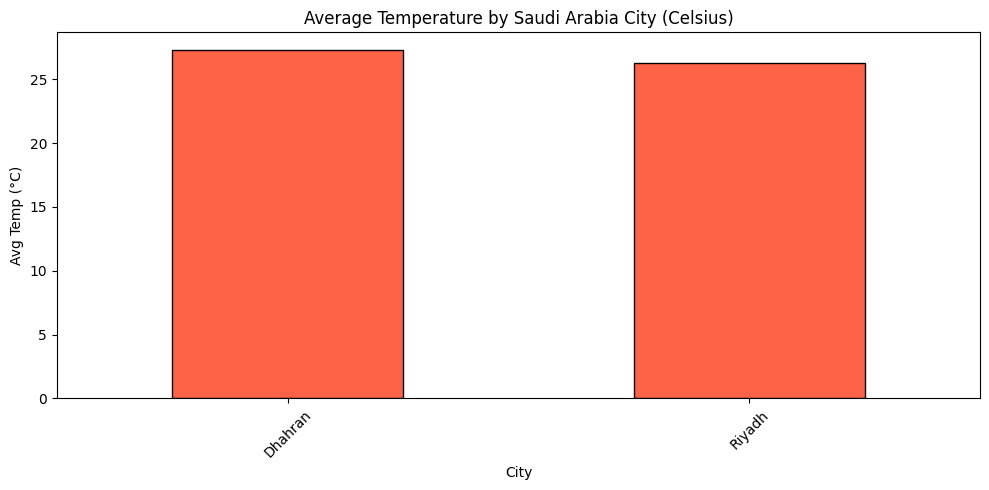

<Figure size 1000x500 with 0 Axes>

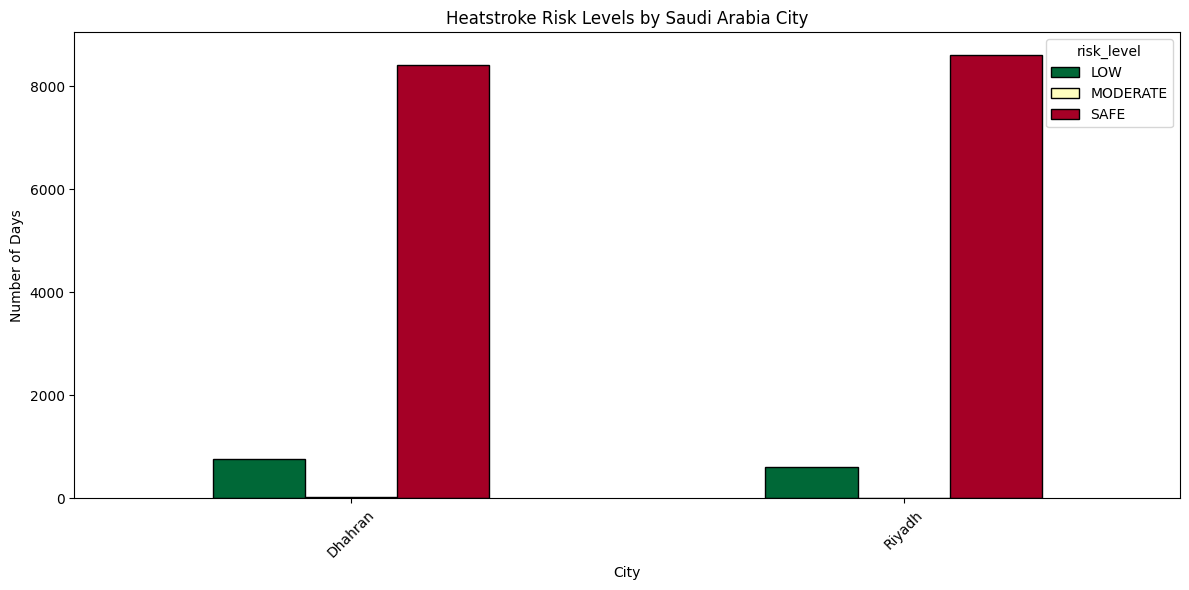

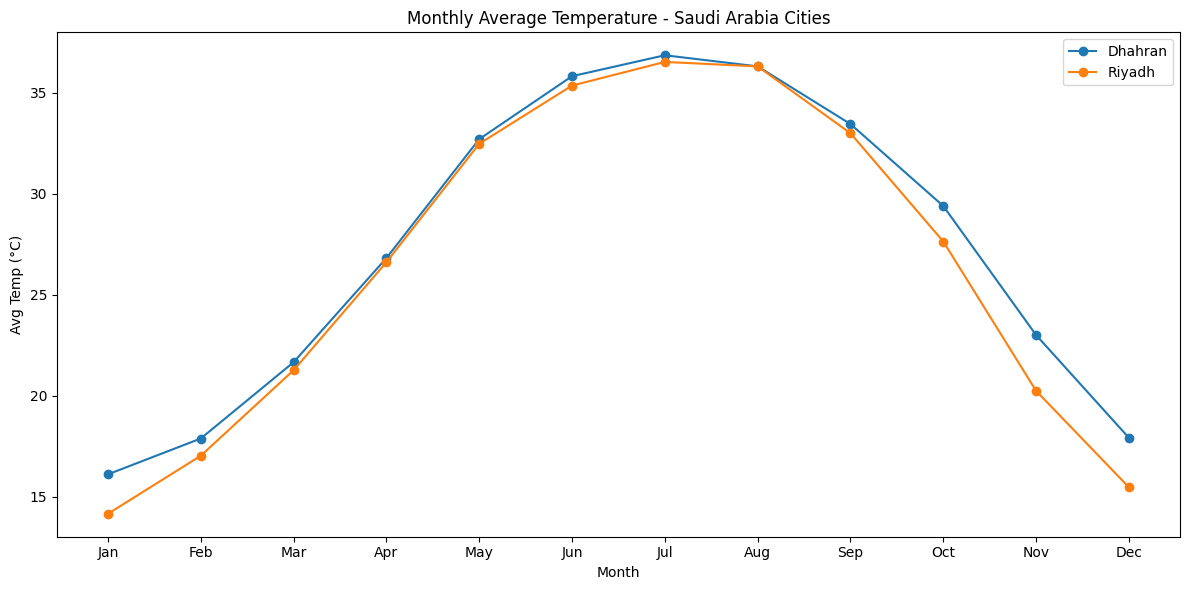

In [17]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cell 2: Load Data
df = pd.read_csv(r'G:\Hajj_Heatstroke\daily_temparature_major_cities.csv', low_memory=False)

# Cell 3: Find Saudi Arabia cities
print("All Saudi Arabia cities in dataset:")
print(df[df['Country'] == 'Saudi Arabia']['City'].unique())

# Cell 4: Filter Saudi Arabia cities & clean data
df_saudi = df[df['Country'] == 'Saudi Arabia'].copy()

# Remove invalid temperatures (-99 is placeholder for missing)
df_saudi = df_saudi[df_saudi['AvgTemperature'] != -99]
df_saudi = df_saudi.dropna(subset=['AvgTemperature'])

# Convert Fahrenheit to Celsius
df_saudi['temp_celsius'] = (df_saudi['AvgTemperature'] - 32) * 5 / 9

# Cell 5: Basic statistics per city
print("\n--- Temperature Statistics by City (Celsius) ---")
stats = df_saudi.groupby('City')['temp_celsius'].agg(['mean', 'max', 'min']).round(2)
stats.columns = ['Average', 'Max', 'Min']
print(stats)

# Cell 6: Heatstroke Risk Function
def assign_risk(temp_celsius):
    if temp_celsius > 46:
        return 'EXTREME'
    elif temp_celsius > 43:
        return 'HIGH'
    elif temp_celsius > 40:
        return 'MODERATE'
    elif temp_celsius > 37:
        return 'LOW'
    else:
        return 'SAFE'

df_saudi['risk_level'] = df_saudi['temp_celsius'].apply(assign_risk)

# Cell 7: Risk distribution per city
print("\n--- Heatstroke Risk Distribution by City ---")
print(df_saudi.groupby(['City', 'risk_level']).size().unstack(fill_value=0))

# Cell 8: Plot - Average Temperature by City
plt.figure(figsize=(10, 5))
stats['Average'].plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Average Temperature by Saudi Arabia City (Celsius)')
plt.xlabel('City')
plt.ylabel('Avg Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cell 9: Plot - Risk Level Distribution
plt.figure(figsize=(10, 5))
df_saudi.groupby(['City', 'risk_level']).size().unstack(fill_value=0).plot(
    kind='bar', figsize=(12, 6), colormap='RdYlGn_r', edgecolor='black'
)
plt.title('Heatstroke Risk Levels by Saudi Arabia City')
plt.xlabel('City')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cell 10: Monthly avg temperature trend for all Saudi cities
plt.figure(figsize=(12, 6))
for city in df_saudi['City'].unique():
    city_data = df_saudi[df_saudi['City'] == city].groupby('Month')['temp_celsius'].mean()
    plt.plot(city_data.index, city_data.values, marker='o', label=city)

plt.title('Monthly Average Temperature - Saudi Arabia Cities')
plt.xlabel('Month')
plt.ylabel('Avg Temp (°C)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Hottest months (Hajj is usually Jun-Aug)
hajj_months = df_saudi[df_saudi['Month'].isin([6, 7, 8])]
print(hajj_months.groupby('City')['temp_celsius'].mean())

City
Dhahran    36.336274
Riyadh     36.071965
Name: temp_celsius, dtype: float64


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Features & target
X = df_saudi[['Month', 'Day', 'Year', 'temp_celsius']]
y = df_saudi['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


--- Hajj Season Temperature Statistics ---
          mean    max    min
City                        
Dhahran  36.34  42.11  27.00
Riyadh   36.07  40.56  30.89


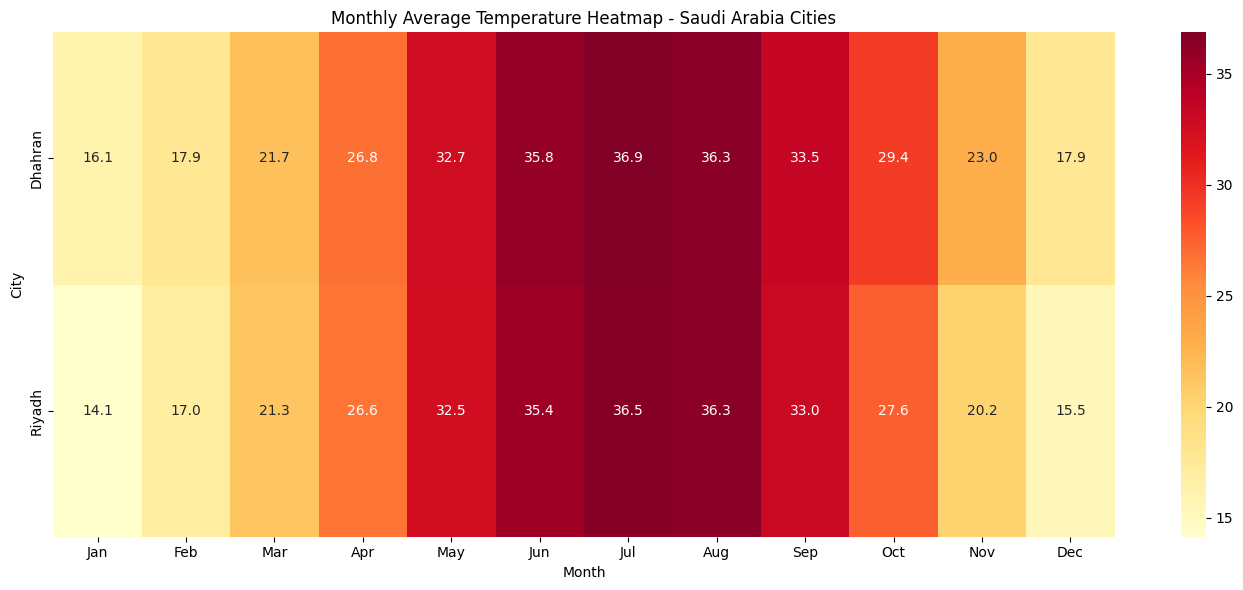

<Figure size 1000x500 with 0 Axes>

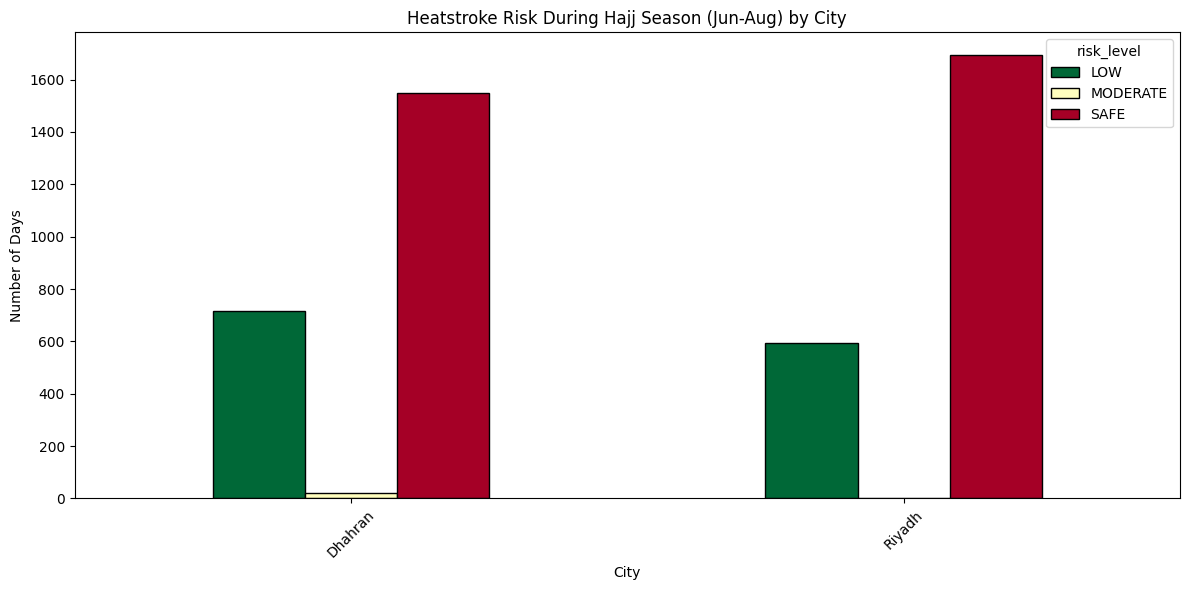

<Figure size 1200x500 with 0 Axes>

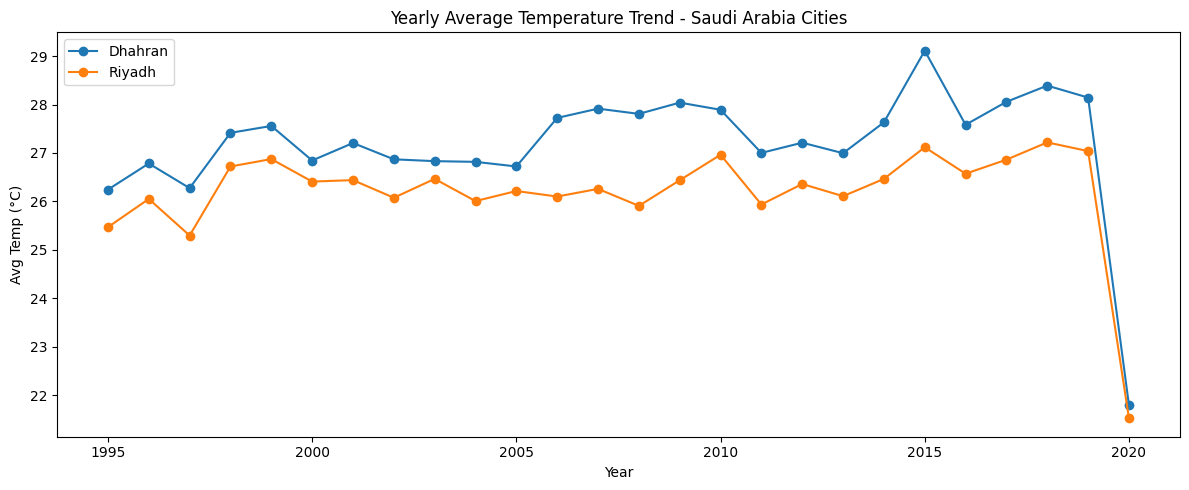

In [20]:
# Cell 11: Filter Hajj Season (June, July, August)
df_hajj = df_saudi[df_saudi['Month'].isin([6, 7, 8])].copy()

print("--- Hajj Season Temperature Statistics ---")
print(df_hajj.groupby('City')['temp_celsius'].agg(['mean', 'max', 'min']).round(2))

# Cell 12: Heatmap - Monthly Avg Temp by City
pivot = df_saudi.groupby(['City', 'Month'])['temp_celsius'].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Monthly Average Temperature Heatmap - Saudi Arabia Cities')
plt.xlabel('Month')
plt.ylabel('City')
plt.tight_layout()
plt.show()

# Cell 13: Hajj Season Risk Count per City
plt.figure(figsize=(10, 5))
df_hajj.groupby(['City', 'risk_level']).size().unstack(fill_value=0).plot(
    kind='bar', colormap='RdYlGn_r', edgecolor='black', figsize=(12, 6))
plt.title('Heatstroke Risk During Hajj Season (Jun-Aug) by City')
plt.xlabel('City')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cell 14: Year-wise Temperature Trend
plt.figure(figsize=(12, 5))
yearly = df_saudi.groupby(['Year', 'City'])['temp_celsius'].mean().unstack()
yearly.plot(figsize=(12, 5), marker='o')
plt.title('Yearly Average Temperature Trend - Saudi Arabia Cities')
plt.xlabel('Year')
plt.ylabel('Avg Temp (°C)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Model Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00       276
    MODERATE       1.00      1.00      1.00         5
        SAFE       1.00      1.00      1.00      3403

    accuracy                           1.00      3684
   macro avg       1.00      1.00      1.00      3684
weighted avg       1.00      1.00      1.00      3684



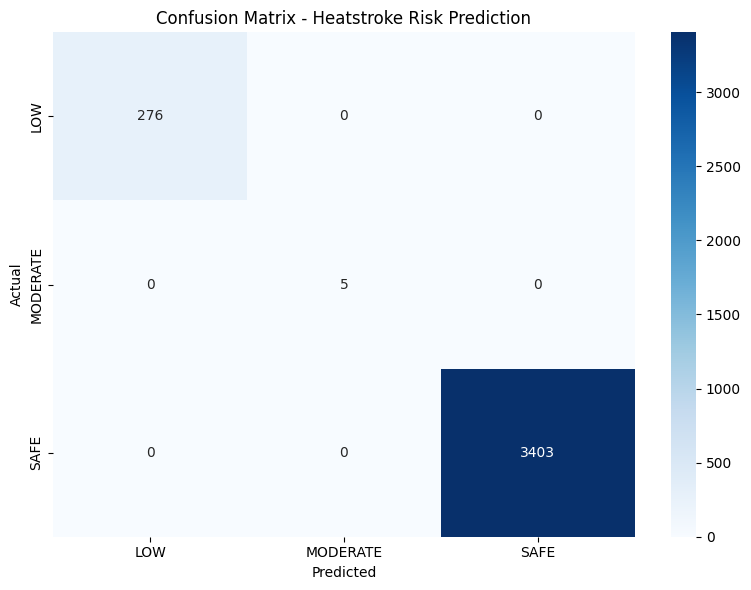

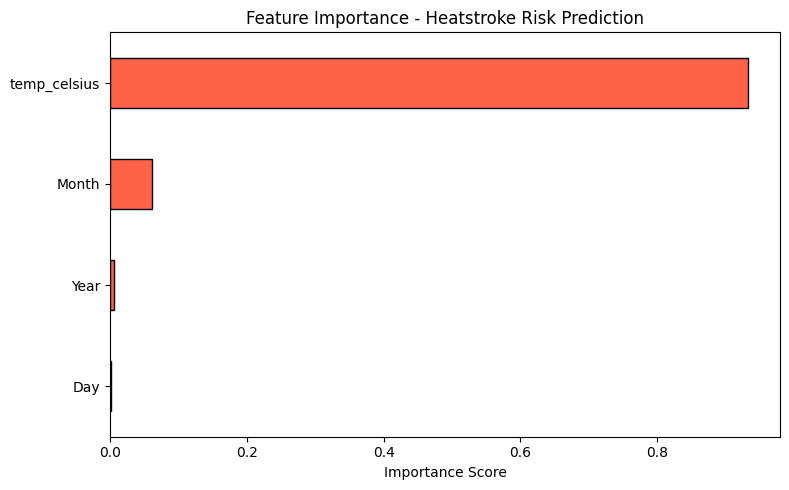

In [21]:
# Cell 15: Machine Learning - Heatstroke Risk Prediction
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# Prepare features
df_ml = df_saudi[['Month', 'Day', 'Year', 'temp_celsius', 'risk_level']].dropna()

# Encode risk labels
le = LabelEncoder()
df_ml['risk_encoded'] = le.fit_transform(df_ml['risk_level'])

X = df_ml[['Month', 'Day', 'Year', 'temp_celsius']]
y = df_ml['risk_encoded']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Accuracy
print("Model Accuracy:", round(model.score(X_test, y_test) * 100, 2), "%")

# Classification Report
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Cell 16: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Heatstroke Risk Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Cell 17: Feature Importance
plt.figure(figsize=(8, 5))
feat_importance = pd.Series(model.feature_importances_,
                            index=['Month', 'Day', 'Year', 'temp_celsius'])
feat_importance.sort_values().plot(kind='barh', color='tomato', edgecolor='black')
plt.title('Feature Importance - Heatstroke Risk Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

   HAJJ HEATSTROKE RISK ANALYSIS - FINAL SUMMARY

📍 Cities Analyzed: ['Dhahran', 'Riyadh']

🌡️ Hajj Season (Jun-Aug) Average Temperatures:
City
Dhahran    36.34
Riyadh     36.07

⚠️ Risk Level Distribution During Hajj Season:
risk_level
SAFE        3246
LOW         1309
MODERATE      23

🔥 Hottest Day Recorded:
   City: Dhahran, Temp: 42.11°C
   Date: 7/1/2016

❄️ Coldest Day Recorded:
   City: Riyadh, Temp: 3.33°C
   Date: 1/16/2008


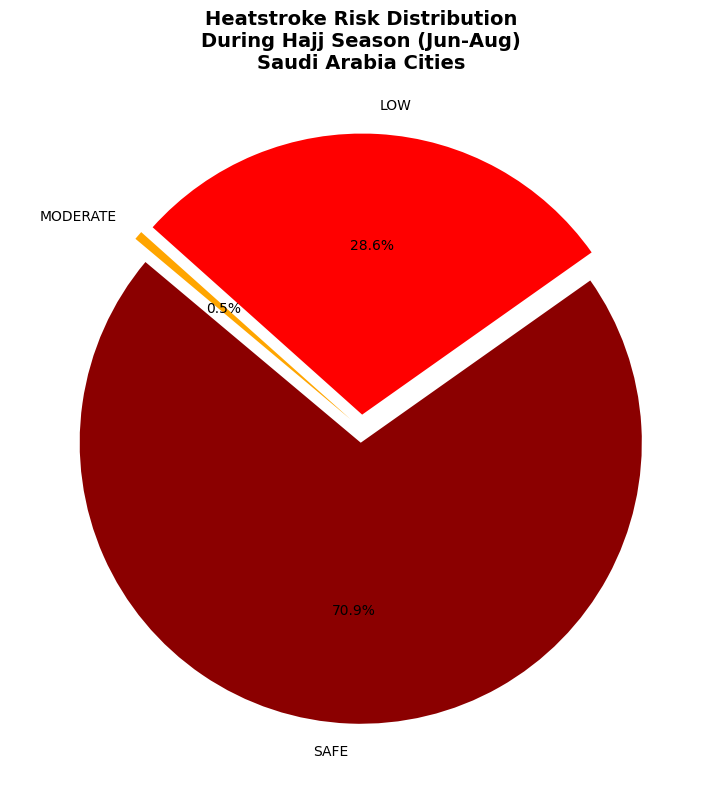


           RECOMMENDATIONS FOR HAJJ PILGRIMS

1. 🕐 Avoid outdoor activities between 11AM - 4PM
2. 💧 Drink at least 3-4 liters of water daily
3. 🧣 Wear loose, light-colored clothing
4. ☂️  Use umbrellas and seek shade frequently
5. 🏥 Know nearest medical centers location
6. 👴 Elderly & sick pilgrims need extra care
7. 📱 Monitor daily temperature forecasts
8. 🌬️  Stay in air-conditioned areas when possible

        PROJECT COMPLETE ✅


In [22]:
# Cell 18: Hajj Season Danger Analysis
print("=" * 55)
print("   HAJJ HEATSTROKE RISK ANALYSIS - FINAL SUMMARY")
print("=" * 55)

hajj = df_saudi[df_saudi['Month'].isin([6, 7, 8])]

print("\n📍 Cities Analyzed:", df_saudi['City'].unique().tolist())
print("\n🌡️ Hajj Season (Jun-Aug) Average Temperatures:")
print(hajj.groupby('City')['temp_celsius'].mean().round(2).to_string())

print("\n⚠️ Risk Level Distribution During Hajj Season:")
print(hajj['risk_level'].value_counts().to_string())

print("\n🔥 Hottest Day Recorded:")
hottest = df_saudi.loc[df_saudi['temp_celsius'].idxmax()]
print(f"   City: {hottest['City']}, Temp: {hottest['temp_celsius']:.2f}°C")
print(f"   Date: {int(hottest['Month'])}/{int(hottest['Day'])}/{int(hottest['Year'])}")

print("\n❄️ Coldest Day Recorded:")
coldest = df_saudi.loc[df_saudi['temp_celsius'].idxmin()]
print(f"   City: {coldest['City']}, Temp: {coldest['temp_celsius']:.2f}°C")
print(f"   Date: {int(coldest['Month'])}/{int(coldest['Day'])}/{int(coldest['Year'])}")

# Cell 19: Final Recommendation Chart
risk_counts = hajj['risk_level'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['darkred', 'red', 'orange', 'green', 'lightgreen']
plt.pie(risk_counts.values,
        labels=risk_counts.index,
        autopct='%1.1f%%',
        colors=colors[:len(risk_counts)],
        startangle=140,
        explode=[0.05] * len(risk_counts))
plt.title('Heatstroke Risk Distribution\nDuring Hajj Season (Jun-Aug)\nSaudi Arabia Cities',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cell 20: Recommendations
print("\n" + "=" * 55)
print("           RECOMMENDATIONS FOR HAJJ PILGRIMS")
print("=" * 55)
print("""
1. 🕐 Avoid outdoor activities between 11AM - 4PM
2. 💧 Drink at least 3-4 liters of water daily
3. 🧣 Wear loose, light-colored clothing
4. ☂️  Use umbrellas and seek shade frequently
5. 🏥 Know nearest medical centers location
6. 👴 Elderly & sick pilgrims need extra care
7. 📱 Monitor daily temperature forecasts
8. 🌬️  Stay in air-conditioned areas when possible
""")

print("=" * 55)
print("        PROJECT COMPLETE ✅")
print("=" * 55)